In [1]:
import os
from pathlib import Path
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False, edgeitems=7)
pd.set_option('display.width', 140)

# Checking for relevant features

In [3]:
df = pd.read_csv('../../../data/cleaned_data/cleaned_pull_count.csv').drop('Unnamed: 0', axis=1)

In [4]:
df

,pulled_count_TARGET_VARIABLE,rarity,weapon,element,region,asc_stat_bonus_category,3D-model,lvl_90_HP,lvl_90_ATK,lvl_90_DEF,...,is_archon,is_standard_banner,role_Off_Field,role_On_Field,role_Support,role_Survivability,role_DPS,duplicate_rate,c6_rate,avg_copies_per_player
0,1338383,4,Sword,Anemo,Fontaine,Anemo DMG Bonus,Medium Female,12397,232,712,...,0,1,1,0,0,0,1,0.774796,0.036392,4.440421
1,93049,5,Catalyst,Electro,Natlan,CRIT Rate,Medium Female,12699,356,782,...,0,0,0,1,0,0,1,0.256102,0.036035,1.344270
2,4277322,4,Claymore,Cryo,Liyue,ATK%,Medium Male,10984,223,648,...,0,1,1,0,1,0,1,0.688872,0.023110,3.214113
3,717953,5,Bow,Dendro,Sumeru,Dendro DMG Bonus,Medium Male,10850,268,630,...,0,1,0,1,0,0,1,0.050633,0.001336,1.053333
4,1341413,5,Sword,Anemo,Mondstadt,Healing Bonus,Tall Female,14695,239,769,...,0,1,1,0,0,1,0,0.036889,0.000031,1.038302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,420336,5,Catalyst,Hydro,Inazuma,Hydro DMG Bonus,Medium Female,13471,234,657,...,0,0,1,0,1,1,0,0.110985,0.006595,1.124840
99,340340,5,Claymore,Cryo,Mondstadt,CRIT DMG,Tall Female,13226,342,751,...,0,0,0,1,0,0,1,0.200414,0.034060,1.250648
100,181138,5,Catalyst,Pyro,Mondstadt,Pyro DMG Bonus,Short Female,10287,311,615,...,0,0,0,1,0,0,1,0.109530,0.004869,1.123002
101,400978,5,Bow,Cryo,Liyue,CRIT DMG,Medium Female,9797,335,630,...,0,0,0,1,0,0,1,0.166468,0.018976,1.199714


In [5]:
df.columns

Index(['pulled_count_TARGET_VARIABLE', 'rarity', 'weapon', 'element', 'region', 'asc_stat_bonus_category', '3D-model', 'lvl_90_HP',
       'lvl_90_ATK', 'lvl_90_DEF', 'months_since_release', 'num_banners', 'is_archon', 'is_standard_banner', 'role_Off_Field',
       'role_On_Field', 'role_Support', 'role_Survivability', 'role_DPS', 'duplicate_rate', 'c6_rate', 'avg_copies_per_player'],
      dtype='str')

In [6]:
df.sort_values(by='months_since_release', ascending=False, inplace=True, ignore_index=True)

In [7]:
df

,pulled_count_TARGET_VARIABLE,rarity,weapon,element,region,asc_stat_bonus_category,3D-model,lvl_90_HP,lvl_90_ATK,lvl_90_DEF,...,is_archon,is_standard_banner,role_Off_Field,role_On_Field,role_Support,role_Survivability,role_DPS,duplicate_rate,c6_rate,avg_copies_per_player
0,4277322,4,Claymore,Cryo,Liyue,ATK%,Medium Male,10984,223,648,...,0,1,1,0,1,0,1,0.688872,0.023110,3.214113
1,1342803,5,Sword,Electro,Liyue,CRIT DMG,Medium Female,13103,323,799,...,0,1,0,1,0,0,1,0.037670,0.000016,1.039145
2,1341413,5,Sword,Anemo,Mondstadt,Healing Bonus,Tall Female,14695,239,769,...,0,1,1,0,0,1,0,0.036889,0.000031,1.038302
3,6183960,4,Sword,Hydro,Liyue,ATK%,Medium Male,10222,202,758,...,0,1,1,0,0,1,1,0.768028,0.035901,4.310870
4,1334757,5,Sword,Cryo,Liyue,Healing Bonus,Short Female,12368,287,922,...,0,1,1,0,0,1,0,0.037775,0.000026,1.039258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,419747,4,Claymore,Hydro,Nod-Krai,Elemental Mastery,Short Female,11201,242,607,...,0,1,1,0,0,0,1,0.864923,0.050130,7.403206
99,134582,5,Polearm,Electro,Nod-Krai,CRIT DMG,Tall Male,12491,352,809,...,0,0,0,1,0,0,1,0.393106,0.041818,1.647734
100,72343,5,Catalyst,Dendro,Nod-Krai,CRIT DMG,Tall Female,12704,344,799,...,0,0,0,1,0,0,1,0.242041,0.059992,1.319333
101,183773,4,Bow,Anemo,Nod-Krai,Healing Bonus,Medium Female,9646,223,580,...,0,1,1,0,1,1,0,0.820006,0.062278,5.555747


In [8]:
df.isna().sum()

pulled_count_TARGET_VARIABLE    0
rarity                          0
weapon                          0
element                         0
region                          0
asc_stat_bonus_category         0
3D-model                        0
lvl_90_HP                       0
lvl_90_ATK                      0
lvl_90_DEF                      0
months_since_release            0
num_banners                     0
is_archon                       0
is_standard_banner              0
role_Off_Field                  0
role_On_Field                   0
role_Support                    0
role_Survivability              0
role_DPS                        0
duplicate_rate                  0
c6_rate                         0
avg_copies_per_player           0
dtype: int64

In [9]:
df.describe(include=(np.number))

,pulled_count_TARGET_VARIABLE,rarity,lvl_90_HP,lvl_90_ATK,lvl_90_DEF,months_since_release,num_banners,is_archon,is_standard_banner,role_Off_Field,role_On_Field,role_Support,role_Survivability,role_DPS,duplicate_rate,c6_rate,avg_copies_per_player
count,1.030000e+02,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,1.562093e+06,4.563107,11905.077670,259.786408,704.757282,37.277734,4.834951,0.058252,0.514563,0.601942,0.407767,0.310680,0.349515,0.640777,0.442079,0.033769,2.542524
std,1.921422e+06,0.498427,1621.564112,60.582087,103.449662,20.404115,3.486942,0.235365,0.502232,0.491891,0.493822,0.465035,0.479148,0.482119,0.282893,0.020852,1.612235
min,1.685400e+04,4.000000,9189.000000,106.000000,500.000000,1.049180,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.036889,0.000016,1.038302
25%,2.247980e+05,4.000000,10470.000000,213.500000,615.000000,18.950820,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.193033,0.023742,1.239312
50%,6.520850e+05,5.000000,12289.000000,244.000000,712.000000,38.622951,4.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.338379,0.033027,1.511439
75%,2.261590e+06,5.000000,12968.500000,320.500000,784.000000,57.426230,6.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.744453,0.042154,3.913222
max,7.659164e+06,5.000000,15675.000000,359.000000,959.000000,63.081967,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.874534,0.137855,7.970314


In [10]:
print(df[['c6_rate', 'duplicate_rate', 'avg_copies_per_player', 'pulled_count_TARGET_VARIABLE']].corr()) # Coorelation between 'owner dependant' variables

                               c6_rate  duplicate_rate  avg_copies_per_player  pulled_count_TARGET_VARIABLE
c6_rate                       1.000000        0.350611               0.279921                     -0.064612
duplicate_rate                0.350611        1.000000               0.926638                      0.627446
avg_copies_per_player         0.279921        0.926638               1.000000                      0.529190
pulled_count_TARGET_VARIABLE -0.064612        0.627446               0.529190                      1.000000


In [11]:
from scipy.special import logit

df['avg_copies_log'] = np.log1p(df['avg_copies_per_player'])
df['pull_count_log'] = np.log1p(df['pulled_count_TARGET_VARIABLE'])
df['c6_rate_logit'] = logit(df['c6_rate'].clip(1e-4, 1-1e-4))
df['duplicate_rate_logit'] = logit(df['duplicate_rate'].clip(1e-4, 1-1e-4))

categorical_cols = ['weapon', 'element', 'region', 'asc_stat_bonus_category', '3D-model']
numeric_cols = ['lvl_90_HP', 'lvl_90_ATK', 'lvl_90_DEF', 'months_since_release', 'num_banners'] # Removed the 'owner dependant' variables
binary_cols = ['is_archon', 'is_standard_banner', 'role_Off_Field', 'role_On_Field',
               'role_Support', 'role_Survivability', 'role_DPS']

In [12]:
print(df[['c6_rate_logit', 'duplicate_rate_logit', 'avg_copies_log', 'pull_count_log']].corr()) # Coorelation between 'owner dependant' variables

                      c6_rate_logit  duplicate_rate_logit  avg_copies_log  pull_count_log
c6_rate_logit              1.000000              0.621761        0.398417       -0.075817
duplicate_rate_logit       0.621761              1.000000        0.946096        0.593018
avg_copies_log             0.398417              0.946096        1.000000        0.659708
pull_count_log            -0.075817              0.593018        0.659708        1.000000


In [13]:
X = df[numeric_cols + binary_cols]
y = (df['rarity'] == 5).astype(int)

In [14]:
from scipy import stats

for col in numeric_cols:
    group4 = df[df['rarity']==4][col]
    group5 = df[df['rarity']==5][col]
    t_stat, p_val = stats.ttest_ind(group4, group5)
    print(f"{col}: p={p_val:.4f}")

lvl_90_HP: p=0.0000
lvl_90_ATK: p=0.0000
lvl_90_DEF: p=0.0012
months_since_release: p=0.2037
num_banners: p=0.0000


In [15]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['rarity'])
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    print(f"{col}: p={p_val:.4f}")

weapon: p=0.2924
element: p=0.9158
region: p=0.6856
asc_stat_bonus_category: p=0.0000
3D-model: p=0.1040


In [16]:
numeric_df = df[numeric_cols]
numeric_df.corrwith(y).sort_values(key=abs, ascending=False)

lvl_90_ATK              0.616367
lvl_90_HP               0.526234
num_banners            -0.515738
lvl_90_DEF              0.315454
months_since_release   -0.126279
dtype: float64

In [17]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print(mi_series.head(15))

is_standard_banner      0.431181
lvl_90_HP               0.314420
lvl_90_ATK              0.282609
lvl_90_DEF              0.202703
num_banners             0.136972
role_DPS                0.074390
is_archon               0.049256
role_On_Field           0.041362
months_since_release    0.000000
role_Off_Field          0.000000
role_Support            0.000000
role_Survivability      0.000000
dtype: float64


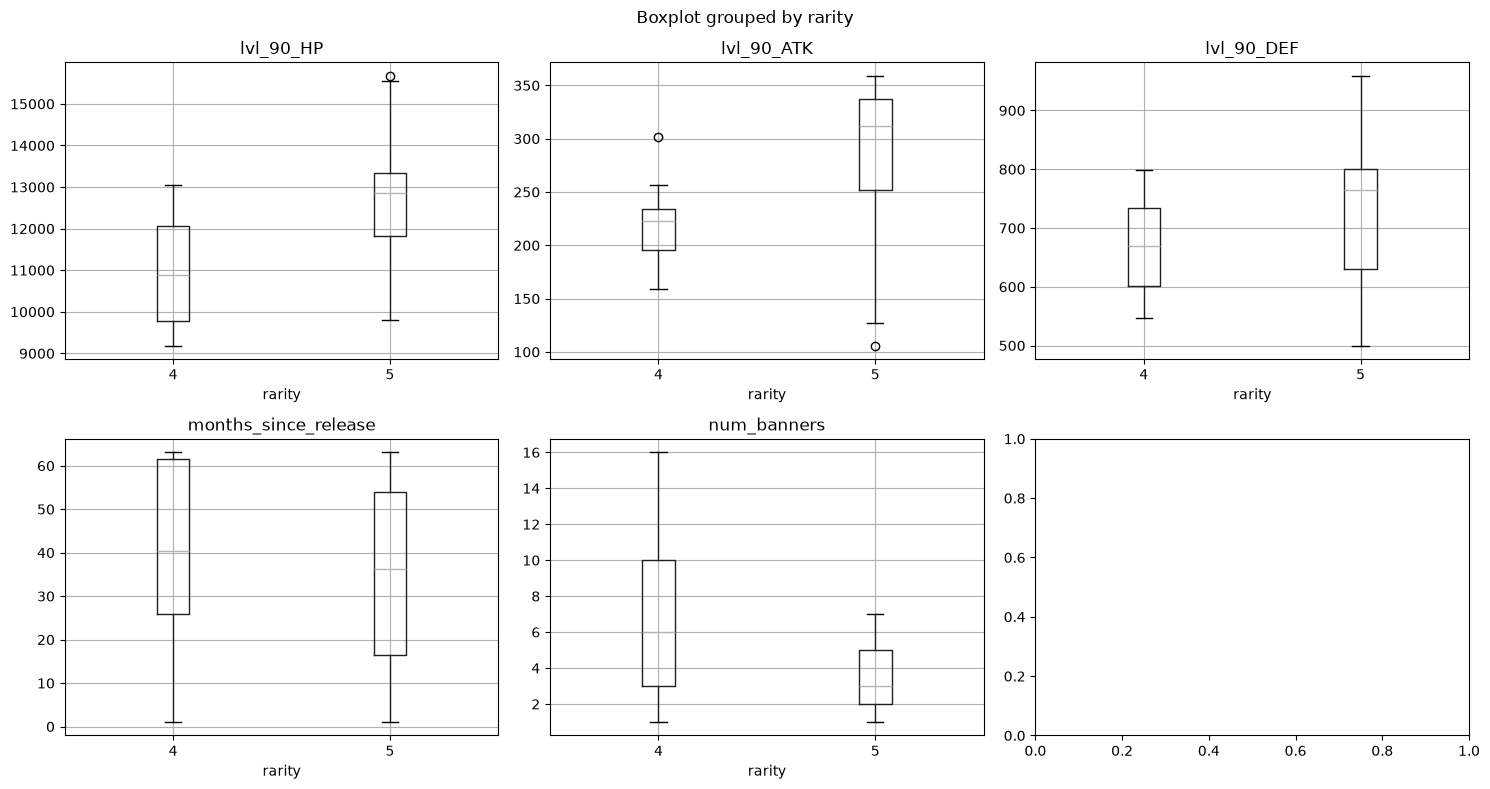

In [18]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flat, numeric_cols):
    df.boxplot(column=col, by='rarity', ax=ax)
plt.tight_layout()

# With pre-built models

In [19]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(l1_ratios=(1.0,), solver='liblinear', cv=5, Cs=10,
                          scoring='accuracy', max_iter=1000, use_legacy_attributes=False)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv)
print(f"Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

Accuracy: 0.962 ± 0.036


In [20]:
model.fit(X, y)
coefs = model.named_steps['logisticregressioncv'].coef_[0]
importance = pd.Series(coefs, index=X.columns).sort_values(key=abs, ascending=False)
print(importance[importance != 0])

num_banners            -9.431459
is_standard_banner     -7.636500
months_since_release    5.322861
role_Survivability      3.155739
lvl_90_ATK              1.499773
role_DPS                1.132842
role_Off_Field         -1.074119
role_On_Field           0.664875
lvl_90_HP               0.243602
dtype: float64


In [21]:
from sklearn.utils import resample

coef_list = []
for i in range(200):
    X_bs, y_bs = resample(X, y, random_state=i)
    m = make_pipeline(StandardScaler(), LogisticRegressionCV(l1_ratios=(1.0,), solver='liblinear', cv=5, max_iter=1000, scoring=None, use_legacy_attributes=False))
    m.fit(X_bs, y_bs)
    coef_list.append(m.named_steps['logisticregressioncv'].coef_[0])

coef_df = pd.DataFrame(coef_list, columns=X.columns)
print(coef_df.mean().sort_values(key=abs, ascending=False))
print(coef_df.std().sort_values(ascending=False))  # high std = unstable feature

is_standard_banner     -4.999282
num_banners            -4.859317
months_since_release    2.571208
lvl_90_ATK              1.261069
role_Survivability      1.071328
lvl_90_HP               0.907468
role_DPS                0.475000
role_Off_Field         -0.346397
role_On_Field           0.222472
lvl_90_DEF              0.135245
role_Support            0.126769
is_archon               0.061997
dtype: float64
num_banners             3.201861
is_standard_banner      2.626433
months_since_release    2.117228
role_Survivability      1.834676
lvl_90_ATK              1.286021
lvl_90_HP               1.062718
role_DPS                0.893880
lvl_90_DEF              0.851443
role_Off_Field          0.636133
role_On_Field           0.525895
role_Support            0.405237
is_archon               0.204897
dtype: float64


In [22]:
role_cols = ['role_Off_Field', 'role_On_Field', 'role_Support', 'role_Survivability', 'role_DPS']
for col in role_cols:
    contingency = pd.crosstab(df[col], df['rarity'])
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    print(f"{col}: p={p_val:.4f}")

role_Off_Field: p=0.0026
role_On_Field: p=0.0015
role_Support: p=0.8366
role_Survivability: p=0.0162
role_DPS: p=0.0024


In [23]:
role_cols = ['role_Off_Field', 'role_On_Field', 'role_Support', 'role_Survivability', 'role_DPS']
print(df[role_cols].corr())

                    role_Off_Field  role_On_Field  role_Support  role_Survivability  role_DPS
role_Off_Field            1.000000      -0.980023      0.460218            0.471297 -0.567530
role_On_Field            -0.980023       1.000000     -0.428989           -0.483935  0.580103
role_Support              0.460218      -0.428989      1.000000            0.167880 -0.503085
role_Survivability        0.471297      -0.483935      0.167880            1.000000 -0.597045
role_DPS                 -0.567530       0.580103     -0.503085           -0.597045  1.000000


In [24]:
for col in role_cols:
    print(col, df.groupby(col)['is_standard_banner'].mean())

role_Off_Field role_Off_Field
0    0.341463
1    0.629032
Name: is_standard_banner, dtype: float64
role_On_Field role_On_Field
0    0.639344
1    0.333333
Name: is_standard_banner, dtype: float64
role_Support role_Support
0    0.549296
1    0.437500
Name: is_standard_banner, dtype: float64
role_Survivability role_Survivability
0    0.402985
1    0.722222
Name: is_standard_banner, dtype: float64
role_DPS role_DPS
0    0.729730
1    0.393939
Name: is_standard_banner, dtype: float64


In [25]:
for col in role_cols:
    print(col, df.groupby(col)['rarity'].mean())

role_Off_Field role_Off_Field
0    4.756098
1    4.435484
Name: rarity, dtype: float64
role_On_Field role_On_Field
0    4.426230
1    4.761905
Name: rarity, dtype: float64
role_Support role_Support
0    4.549296
1    4.593750
Name: rarity, dtype: float64
role_Survivability role_Survivability
0    4.656716
1    4.388889
Name: rarity, dtype: float64
role_DPS role_DPS
0    4.351351
1    4.681818
Name: rarity, dtype: float64


In [26]:
X_test = df[['is_standard_banner', 'num_banners', 'lvl_90_ATK', 'lvl_90_HP']]
scores = cross_val_score(model, X_test, y, cv=cv)
print(f"With role_On_Field: {scores.mean():.3f} ± {scores.std():.3f}")

With role_On_Field: 0.941 ± 0.058


In [27]:
X_test = df[['is_standard_banner', 'num_banners', 'lvl_90_ATK', 'lvl_90_HP', 'role_On_Field']]
scores = cross_val_score(model, X_test, y, cv=cv)
print(f"With role_On_Field: {scores.mean():.3f} ± {scores.std():.3f}")

With role_On_Field: 0.932 ± 0.051


In [28]:
possible_features = ['is_standard_banner', 'num_banners', 'lvl_90_ATK', 'lvl_90_HP']

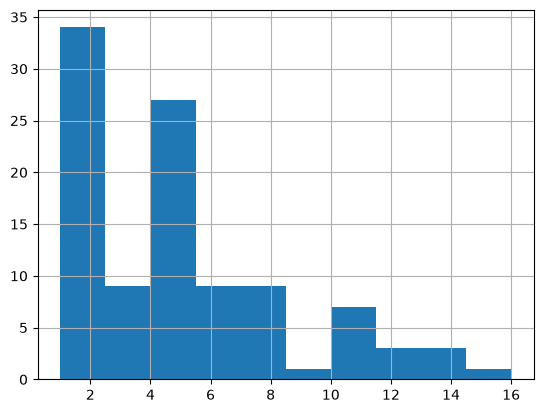

In [29]:
df['num_banners'].hist();

In [30]:
df['num_banners_log'] = np.log1p(df['num_banners'])

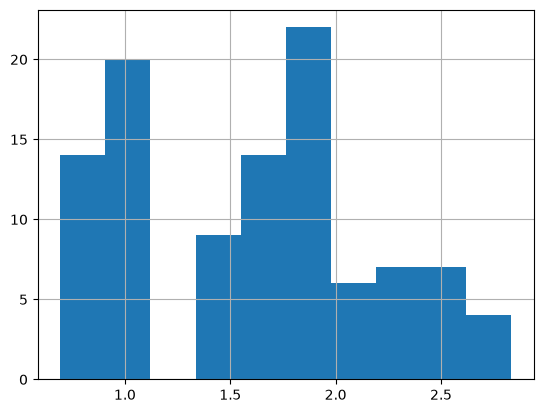

In [31]:
df['num_banners_log'].hist();

In [32]:
# t-test
group4 = df[df['rarity']==4]['num_banners_log']
group5 = df[df['rarity']==5]['num_banners_log']
print(stats.ttest_ind(group4, group5))

# correlation with target
print(df[['num_banners_log']].corrwith(y))

TtestResult(statistic=np.float64(5.379697031463477), pvalue=np.float64(4.843788601795344e-07), df=np.float64(101.0))
num_banners_log   -0.471937
dtype: float64


In [33]:
X = df[['is_standard_banner', 'num_banners_log', 'lvl_90_ATK', 'lvl_90_HP']]
scores = cross_val_score(model, X, y, cv=cv)
print(f"Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

Accuracy: 0.951 ± 0.055


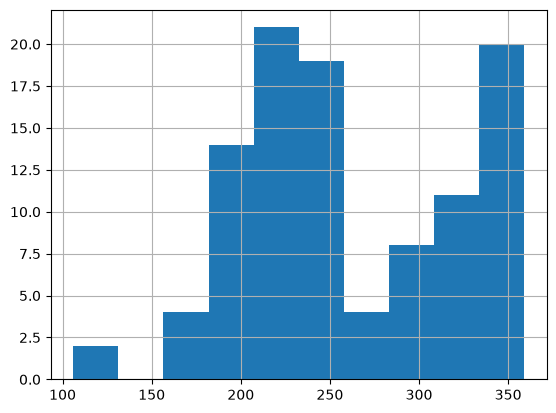

In [34]:
df['lvl_90_ATK'].hist();

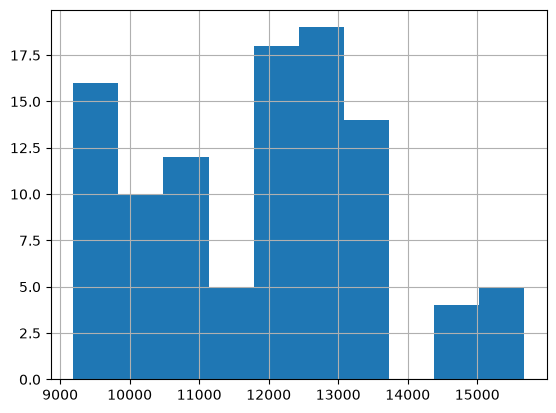

In [35]:
df['lvl_90_HP'].hist();

In [36]:
final_features = ['is_standard_banner', 'num_banners_log', 'lvl_90_ATK', 'lvl_90_HP']

# From-scratch model

In [37]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [38]:
from torch import tensor

t_dep = tensor(y).to(device)
t_dep

tensor([0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
        0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
        0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1], device='cuda:0')

In [39]:
t_indep = tensor(df[final_features].values, dtype=torch.float).to(device)
t_indep

tensor([[    1.0000,     2.3979,   223.0000, 10984.0000],
        [    1.0000,     1.0986,   323.0000, 13103.0000],
        [    1.0000,     0.6931,   239.0000, 14695.0000],
        [    1.0000,     2.7081,   202.0000, 10222.0000],
        [    1.0000,     0.6931,   287.0000, 12368.0000],
        [    1.0000,     0.6931,   287.0000, 10409.0000],
        [    1.0000,     2.4849,   191.0000, 12071.0000],
        [    1.0000,     2.1972,   234.0000, 11962.0000],
        [    1.0000,     2.7081,   225.0000, 10875.0000],
        [    1.0000,     0.6931,   335.0000, 12981.0000],
        [    1.0000,     2.8332,   191.0000, 12397.0000],
        [    1.0000,     2.5649,   170.0000,  9244.0000],
        [    1.0000,     2.4849,   244.0000,  9189.0000],
        [    1.0000,     2.6391,   159.0000,  9787.0000],
        [    1.0000,     2.4849,   225.0000, 13050.0000],
        [    0.0000,     2.0794,   263.0000, 10531.0000],
        [    1.0000,     2.3979,   212.0000,  9787.0000],
        [    0

In [40]:
torch.manual_seed(442)

n_coeff = t_indep.shape[1]
coeffs = (torch.rand(n_coeff)-0.5).to(device)
coeffs

tensor([-0.4629,  0.1386,  0.2409, -0.2262], device='cuda:0')

In [41]:
result = t_indep*coeffs
result

tensor([[    -0.4629,      0.3323,     53.7209,  -2484.0764],
        [    -0.4629,      0.1522,     77.8110,  -2963.2971],
        [    -0.4629,      0.0961,     57.5753,  -3323.3342],
        [    -0.4629,      0.3753,     48.6620,  -2311.7471],
        [    -0.4629,      0.0961,     69.1385,  -2797.0737],
        [    -0.4629,      0.0961,     69.1385,  -2354.0378],
        [    -0.4629,      0.3444,     46.0121,  -2729.9060],
        [    -0.4629,      0.3045,     56.3708,  -2705.2551],
        [    -0.4629,      0.3753,     54.2027,  -2459.4258],
        [    -0.4629,      0.0961,     80.7018,  -2935.7063],
        [    -0.4629,      0.3926,     46.0121,  -2803.6323],
        [    -0.4629,      0.3554,     40.9531,  -2090.5684],
        [    -0.4629,      0.3444,     58.7798,  -2078.1299],
        [    -0.4629,      0.3657,     38.3032,  -2213.3701],
        [    -0.4629,      0.3444,     54.2027,  -2951.3108],
        [    -0.0000,      0.2882,     63.3569,  -2381.6287],
        

In [42]:
max_value,indices = t_indep.max(axis=0)
max_value

tensor([    1.0000,     2.8332,   359.0000, 15675.0000], device='cuda:0')

In [43]:
t_indep = t_indep/max_value
t_indep

tensor([[1.0000, 0.8464, 0.6212, 0.7007],
        [1.0000, 0.3878, 0.8997, 0.8359],
        [1.0000, 0.2447, 0.6657, 0.9375],
        [1.0000, 0.9558, 0.5627, 0.6521],
        [1.0000, 0.2447, 0.7994, 0.7890],
        [1.0000, 0.2447, 0.7994, 0.6641],
        [1.0000, 0.8771, 0.5320, 0.7701],
        [1.0000, 0.7755, 0.6518, 0.7631],
        [1.0000, 0.9558, 0.6267, 0.6938],
        [1.0000, 0.2447, 0.9331, 0.8281],
        [1.0000, 1.0000, 0.5320, 0.7909],
        [1.0000, 0.9053, 0.4735, 0.5897],
        [1.0000, 0.8771, 0.6797, 0.5862],
        [1.0000, 0.9315, 0.4429, 0.6244],
        [1.0000, 0.8771, 0.6267, 0.8325],
        [0.0000, 0.7340, 0.7326, 0.6718],
        [1.0000, 0.8464, 0.5905, 0.6244],
        [0.0000, 0.6324, 0.8663, 0.6563],
        [0.0000, 0.6868, 0.8384, 0.8359],
        [1.0000, 0.9053, 0.5905, 0.6105],
        [1.0000, 0.8464, 0.6936, 0.7146],
        [0.0000, 0.7340, 0.6992, 0.9375],
        [0.0000, 0.5681, 0.6992, 0.8438],
        [0.0000, 0.6324, 0.9331, 0

In [44]:
result = t_indep*coeffs
result

tensor([[-0.4629,  0.1173,  0.1496, -0.1585],
        [-0.4629,  0.0537,  0.2167, -0.1890],
        [-0.4629,  0.0339,  0.1604, -0.2120],
        [-0.4629,  0.1325,  0.1355, -0.1475],
        [-0.4629,  0.0339,  0.1926, -0.1784],
        [-0.4629,  0.0339,  0.1926, -0.1502],
        [-0.4629,  0.1215,  0.1282, -0.1742],
        [-0.4629,  0.1075,  0.1570, -0.1726],
        [-0.4629,  0.1325,  0.1510, -0.1569],
        [-0.4629,  0.0339,  0.2248, -0.1873],
        [-0.4629,  0.1386,  0.1282, -0.1789],
        [-0.4629,  0.1255,  0.1141, -0.1334],
        [-0.4629,  0.1215,  0.1637, -0.1326],
        [-0.4629,  0.1291,  0.1067, -0.1412],
        [-0.4629,  0.1215,  0.1510, -0.1883],
        [-0.0000,  0.1017,  0.1765, -0.1519],
        [-0.4629,  0.1173,  0.1423, -0.1412],
        [-0.0000,  0.0876,  0.2087, -0.1484],
        [-0.0000,  0.0952,  0.2020, -0.1890],
        [-0.4629,  0.1255,  0.1423, -0.1381],
        [-0.4629,  0.1173,  0.1671, -0.1616],
        [-0.0000,  0.1017,  0.1684

In [45]:
preds = result.sum(axis=1)
preds

tensor([-0.3544, -0.3815, -0.4806, -0.3424, -0.4149, -0.3866, -0.3873, -0.3710, -0.3364, -0.3915, -0.3750, -0.3567, -0.3102, -0.3683,
        -0.3787,  0.1263, -0.3446,  0.1479,  0.1081, -0.3333, -0.3401,  0.0581,  0.0563,  0.1711,  0.1456, -0.0656, -0.3537, -0.3152,
         0.1174,  0.1019,  0.1316,  0.1653, -0.3627, -0.3749,  0.1351,  0.0503, -0.3638,  0.0545, -0.3830,  0.0953, -0.3810,  0.1661,
         0.0815,  0.0429, -0.3962, -0.3780, -0.3747, -0.3859, -0.3904, -0.3824,  0.1119,  0.0140,  0.1388, -0.3897, -0.3677,  0.1522,
        -0.3962,  0.0962, -0.4575, -0.4150, -0.4107,  0.0156, -0.4103, -0.4183,  0.1222, -0.4122,  0.0063,  0.0663, -0.4484,  0.0216,
         0.1215, -0.4183,  0.1284, -0.3374,  0.1195,  0.1083,  0.0929, -0.3731, -0.0093,  0.0828, -0.4338, -0.0432,  0.0910,  0.0734,
        -0.3647,  0.1452,  0.1135, -0.0289, -0.3741, -0.4685,  0.1094, -0.3764, -0.4352,  0.0742, -0.4826,  0.0957,  0.0932,  0.0513,
        -0.4282,  0.0899,  0.0814, -0.4185,  0.0874], device='

In [46]:
loss = torch.abs(preds - t_dep).mean()
loss

tensor(0.7206, device='cuda:0')

In [47]:
def calc_preds(coeffs, indeps): return (indeps*coeffs).sum(axis=1)
def calc_loss(coeffs, indeps, deps): return torch.abs(calc_preds(coeffs, indeps)-deps).mean()

In [48]:
print(f'Initial loss: {calc_loss(coeffs, t_indep, t_dep)}')

Initial loss: 0.7205810546875


In [49]:
coeffs.requires_grad_()
coeffs

tensor([-0.4629,  0.1386,  0.2409, -0.2262], device='cuda:0', requires_grad=True)

In [50]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss.backward()

In [51]:
coeffs.grad

tensor([-0.5146, -0.5640, -0.7236, -0.7595], device='cuda:0')

In [52]:
with torch.no_grad():
    coeffs.sub_(coeffs.grad*0.1)
    loss = calc_loss(coeffs, t_indep, t_dep)
    print(loss)

tensor(0.5522, device='cuda:0')


In [53]:
coeffs

tensor([-0.4114,  0.1950,  0.3133, -0.1502], device='cuda:0', requires_grad=True)

In [54]:
trn_split = np.array(range(0, 78))

In [55]:
trn_split

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
       66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77])

In [56]:
val_split = np.array(range(78, 103))

In [57]:
val_split

array([ 78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102])

In [58]:
trn_indep, val_indep = t_indep[trn_split], t_indep[val_split]
trn_dep, val_dep = t_dep[trn_split], t_dep[val_split]

In [59]:
trn_indep.shape, val_indep.shape, trn_dep.shape, val_dep.shape, coeffs.shape

(torch.Size([78, 4]),
 torch.Size([25, 4]),
 torch.Size([78]),
 torch.Size([25]),
 torch.Size([4]))

In [60]:
def update_coeffs(coeffs, lr): coeffs.sub_(coeffs.grad*lr)

In [61]:
def one_epoch(coeffs, lr):
    loss = calc_loss(coeffs, trn_indep, trn_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    print(f"{loss:.3f}", end="; ")

In [62]:
def init_coeffs(): return (torch.rand(n_coeff)-0.3).to(device).requires_grad_()

In [63]:
def train_model(num_epochs=30, lr=0.01):
    torch.manual_seed(442)
    coeffs = init_coeffs()
    for i in range(num_epochs): one_epoch(coeffs, lr)
    return coeffs

In [64]:
coeffs = train_model(59, 0.001)

0.388; 0.388; 0.388; 0.387; 0.386; 0.386; 0.384; 0.383; 0.382; 0.380; 0.378; 0.376; 0.374; 0.372; 0.369; 0.367; 0.364; 0.361; 0.357; 0.354; 0.350; 0.347; 0.343; 0.339; 0.335; 0.330; 0.326; 0.321; 0.316; 0.311; 0.306; 0.301; 0.295; 0.290; 0.284; 0.278; 0.273; 0.267; 0.263; 0.260; 0.257; 0.253; 0.250; 0.246; 0.242; 0.237; 0.232; 0.226; 0.219; 0.212; 0.204; 0.196; 0.187; 0.177; 0.168; 0.159; 0.151; 0.146; 0.144; 

In [65]:
def show_coeffs(): return dict(zip(final_features, coeffs.requires_grad_(False)))
show_coeffs()

{'is_standard_banner': tensor(-0.8063, device='cuda:0'),
 'num_banners_log': tensor(0.3032, device='cuda:0'),
 'lvl_90_ATK': tensor(0.7646, device='cuda:0'),
 'lvl_90_HP': tensor(0.2308, device='cuda:0')}

In [66]:
preds = calc_preds(coeffs, val_indep)

In [67]:
val_dep

tensor([1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1], device='cuda:0')

In [68]:
preds

tensor([ 0.7251,  1.0308, -0.0529,  0.7288,  1.0140,  0.9167, -0.0022,  1.0009,  1.0670,  0.5593, -0.0181, -0.0867,  1.0628,  0.0463,
        -0.1612,  1.0097, -0.1455,  1.0216,  1.0061,  0.7741, -0.0518,  1.0078,  0.9939, -0.1152,  0.9962], device='cuda:0')

In [69]:
results = val_dep.bool()==(preds>0.5)
results

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True], device='cuda:0')

In [70]:
results.float().mean()

tensor(0.9600, device='cuda:0')

In [71]:
def acc(coeffs): return((val_dep.bool()==(calc_preds(coeffs, val_indep)>0.5)).float().mean())

In [72]:
acc(coeffs)

tensor(0.9600, device='cuda:0')

In [73]:
def calc_preds(coeffs, indeps): return torch.sigmoid((indeps*coeffs).sum(axis=1))

In [74]:
coeffs = train_model(lr=1)

0.467; 0.456; 0.435; 0.403; 0.363; 0.317; 0.273; 0.233; 0.198; 0.168; 0.145; 0.127; 0.114; 0.105; 0.099; 0.096; 0.093; 0.092; 0.091; 0.090; 0.090; 0.090; 0.089; 0.089; 0.089; 0.089; 0.089; 0.089; 0.089; 0.089; 

In [75]:
acc(coeffs)

tensor(0.9600, device='cuda:0')

In [76]:
show_coeffs()

{'is_standard_banner': tensor(-19.0728, device='cuda:0'),
 'num_banners_log': tensor(-1.4843, device='cuda:0'),
 'lvl_90_ATK': tensor(9.6273, device='cuda:0'),
 'lvl_90_HP': tensor(7.0734, device='cuda:0')}

In [77]:
(val_indep*coeffs).sum(axis=1)

tensor([ 10.6235,  14.5307,  -8.5048,  11.1574,  14.1299,  12.2462,  -9.0844,  13.1509,  14.7159,   8.0801,  -8.7459,  -7.9232,  14.7018,
         -8.0981, -10.3259,  14.9657,  -8.7242,  14.8674,  13.9657,  11.2829,  -7.8918,  14.7131,  14.5946,  -9.1030,  14.5514],
       device='cuda:0')

In [78]:
val_indep@coeffs

tensor([ 10.6235,  14.5307,  -8.5048,  11.1574,  14.1299,  12.2462,  -9.0844,  13.1509,  14.7159,   8.0801,  -8.7459,  -7.9232,  14.7018,
         -8.0981, -10.3259,  14.9657,  -8.7242,  14.8674,  13.9657,  11.2829,  -7.8918,  14.7131,  14.5946,  -9.1030,  14.5514],
       device='cuda:0')

In [79]:
def calc_preds(coeffs, indeps): return torch.sigmoid(indeps@coeffs)

In [80]:
def init_coeffs(): return (torch.rand(n_coeff, 1)*0.1).to(device).requires_grad_()

In [81]:
trn_dep = trn_dep[:,None]
val_dep = val_dep[:,None]

In [82]:
trn_dep.shape, val_dep.shape

(torch.Size([78, 1]), torch.Size([25, 1]))

In [83]:
coeffs = train_model(lr=1)

0.498; 0.487; 0.465; 0.431; 0.389; 0.341; 0.291; 0.244; 0.203; 0.169; 0.143; 0.124; 0.112; 0.103; 0.098; 0.094; 0.092; 0.091; 0.090; 0.090; 0.089; 0.089; 0.089; 0.089; 0.089; 0.089; 0.089; 0.089; 0.089; 0.089; 

In [84]:
acc(coeffs)

tensor(0.9600, device='cuda:0')

In [85]:
coeffs

tensor([[-19.4524],
        [ -1.7429],
        [  9.9512],
        [  7.5750]], device='cuda:0', requires_grad=True)

In [86]:
def init_coeffs(num_hidden=15):
    layer1 = (torch.rand(n_coeff, num_hidden)-0.5)/num_hidden
    layer2 = (torch.rand(num_hidden, 1))-0.3
    const = torch.rand(1)[0]
    return layer1.to(device).requires_grad_(), layer2.to(device).requires_grad_(), const.to(device).requires_grad_()

In [87]:
import torch.nn.functional as F

In [88]:
def calc_preds(coeffs, indeps):
    l1, l2, const = coeffs
    res = F.relu(indeps@l1)
    res = res@l2 + const
    return torch.sigmoid(res)

In [89]:
def update_coeffs(coeffs, lr):
    for layer in coeffs: layer.sub_(layer.grad*lr)

In [90]:
coeffs = train_model(lr=1)

0.488; 0.482; 0.473; 0.456; 0.436; 0.414; 0.381; 0.333; 0.256; 0.153; 0.105; 0.098; 0.095; 0.093; 0.092; 0.091; 0.090; 0.090; 0.090; 0.090; 0.090; 0.090; 0.090; 0.090; 0.090; 0.090; 0.090; 0.090; 0.090; 0.090; 

In [91]:
acc(coeffs)

tensor(0.9600, device='cuda:0')

In [102]:
def init_coeffs():
    hidden = [10, 10]
    sizes = [n_coeff] + hidden + [1]
    n = len(sizes)
    layers = [((torch.rand(sizes[i], sizes[i+1])-0.3)/sizes[i+1]*4).to(device).requires_grad_() for i in range(n-1)]
    consts = [((torch.rand(1)[0]-0.5)*0.1).to(device).requires_grad_() for i in range(n-1)]
    return layers, consts

In [103]:
def calc_preds(coeffs, indeps):
    layers, consts = coeffs
    n = len(layers)
    res = indeps
    for i,layer in enumerate(layers):
        res = (res@layer) + consts[i]
        if i!=n-1: res = F.relu(res)
    return torch.sigmoid(res)

In [104]:
def update_coeffs(coeffs, lr):
    layers, consts = coeffs
    for layer in layers+consts: layer.sub_(layer.grad*lr)

In [113]:
coeffs = train_model(8,lr=1)

0.506; 0.489; 0.460; 0.416; 0.349; 0.196; 0.107; 0.090; 

In [106]:
acc(coeffs)

tensor(0.9600, device='cuda:0')